In [1]:
# ensure classes imported from .py files are dynamically updated
%load_ext autoreload
%autoreload 2

# plot matplots nicely
%matplotlib inline  

In [2]:
from stericheight.data_handler import *
from stericheight.steric_height import *
from stericheight.plotting_fns import PlottingFns
from load_meop import MEOP
from region import Region
pfns = PlottingFns()

In [3]:
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cmocean
import xesmf as xe
import matplotlib.patches as mpatches


ARGO = '/nfs/b0133/eejco/data/ARGO/DataSelection_a0ad0869-68c3-4b7d-af4c-9c010ab6e378/'


# glaciers = {'mertz ':[144.25,-67.5],
#             'denman':[99.5, -66.75],
#             'conger':[103,-66],
#             'vanderford':[110, -66],
#             'totten':[116.33,-67],
glaciers = {'cook': [153,-69],
            'mertz': [144.25,-67.5]}

extent = [140,170,-70,-60]

In [4]:
#define helper functions
def get_trend(da: xr.DataArray,ns=True):
    ns_2_yr = lambda x: x * 1e9 * 60 * 60 * 24 * 365.25
    p = da.polyfit(dim='time',deg=1)
    m = p.polyfit_coefficients.sel(degree=1)
    m = m.assign_coords(longitude=da.longitude)
    return ns_2_yr(m) if ns else m

def crop_to_extent(ds, extent):
    return ds.where((ds.latitude >= extent[2]) & 
                    (ds.latitude <= extent[3]) &
                    (ds.longitude >= extent[0]) &
                    (ds.longitude <= extent[1]), drop=True)

def season_split(da):
    # divide by season
    months = da.time.dt.month
    seasons = dict()
    seasons['winter'] = da.where((months >=7) & (months <=9))
    seasons['spring'] = da.where((months >=10) & (months <=12))
    seasons['summer'] = da.where((months >=1) & (months <=3))
    seasons['autumn'] = da.where((months >=4) & (months <=6))
    return seasons

def seasonal_anomaly(da):
    return da.groupby('time.month') - da.groupby('time.month').mean()

def plot_glaciers(ax):
    for label in glaciers:
        coords=glaciers[label]
        ax.text(coords[0],coords[1],label,transform=ccrs.PlateCarree(),size=8,c='w',ha='center',bbox=dict(boxstyle="square",facecolor='black',alpha=0.5))



In [5]:
lwe_ds = GRACE().ds
sla = SLA(deg=1).da
sla0 = SLA(deg=0.25).da
dot_ds = DOT().ds

sha_ds_sla = StericHeight(ssh_ref='DOT',
                      ssh=sla,
                      msl=None,
                      lwe=lwe_ds.lwe_thickness
                      ).get_sha()

In [6]:
elevation = GEBCO(coarsen_factor=40).ds.elevation

In [7]:
an = lambda da: da.groupby('time.year').mean()
yr = lambda da: [pd.Timestamp(y.item(),1,1) for y in an(da).year]

In [8]:
sla_anomaly = sla0.groupby('time.month') - sla0.groupby('time.month').mean()

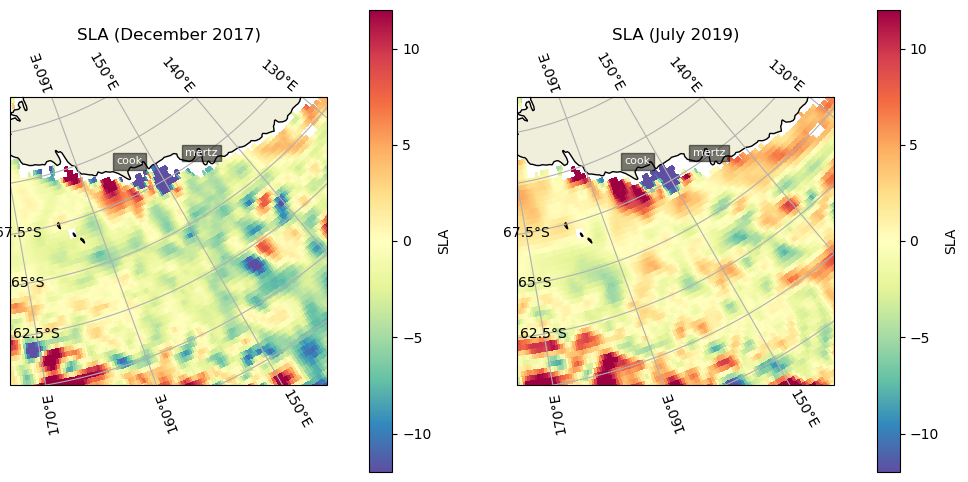

In [9]:
fig, ax = plt.subplots(1,2,figsize=(12,6),subplot_kw={'projection':ccrs.SouthPolarStereo()})
pfns.sp(ax[0],sla0.sel(time=pd.Timestamp(2017,12,1),method='nearest'),cbar='SLA',vmax=12,title='SLA (December 2017)',extent=extent,cbar_orientation='vertical',land_zorder=2)
pfns.sp(ax[1],sla0.sel(time=pd.Timestamp(2019,7,1),method='nearest'),cbar='SLA',vmax=12,title='SLA (July 2019)',extent=extent,cbar_orientation='vertical',land_zorder=2)
plot_glaciers(ax[0])
plot_glaciers(ax[1])

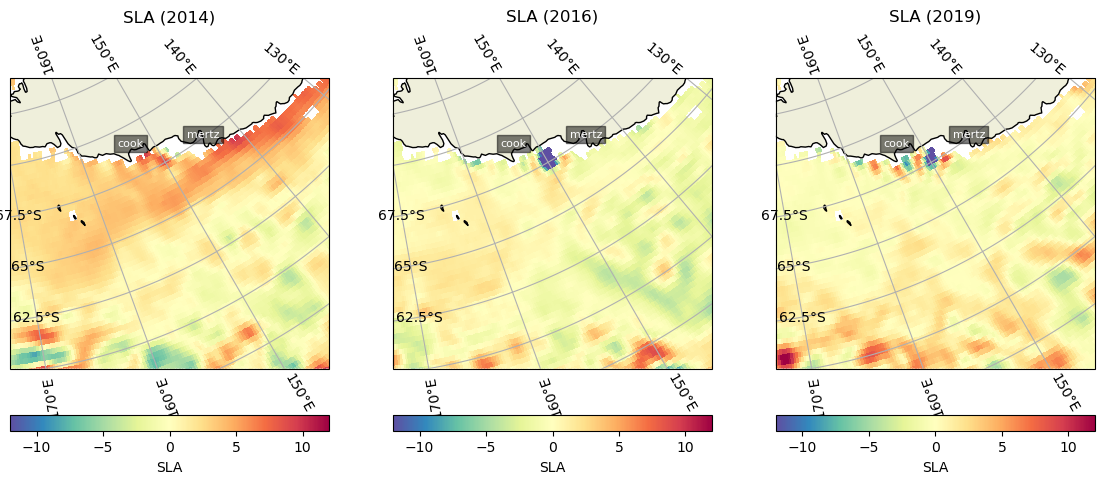

In [32]:
fig, ax = plt.subplots(1,3,figsize=(14,6),subplot_kw={'projection':ccrs.SouthPolarStereo()})
pfns.sp(ax[0],an(sla_anomaly).sel(year=2014),cbar='SLA',vmax=12,title='SLA (2014)',extent=extent,cbar_orientation='horizontal',land_zorder=2)
pfns.sp(ax[1],an(sla_anomaly).sel(year=2016),cbar='SLA',vmax=12,title='SLA (2016)',extent=extent,cbar_orientation='horizontal',land_zorder=2)
pfns.sp(ax[2],an(sla_anomaly).sel(year=2019),cbar='SLA',vmax=12,title='SLA (2019)',extent=extent,cbar_orientation='horizontal',land_zorder=2)
plot_glaciers(ax[0])
plot_glaciers(ax[1])
plot_glaciers(ax[2])


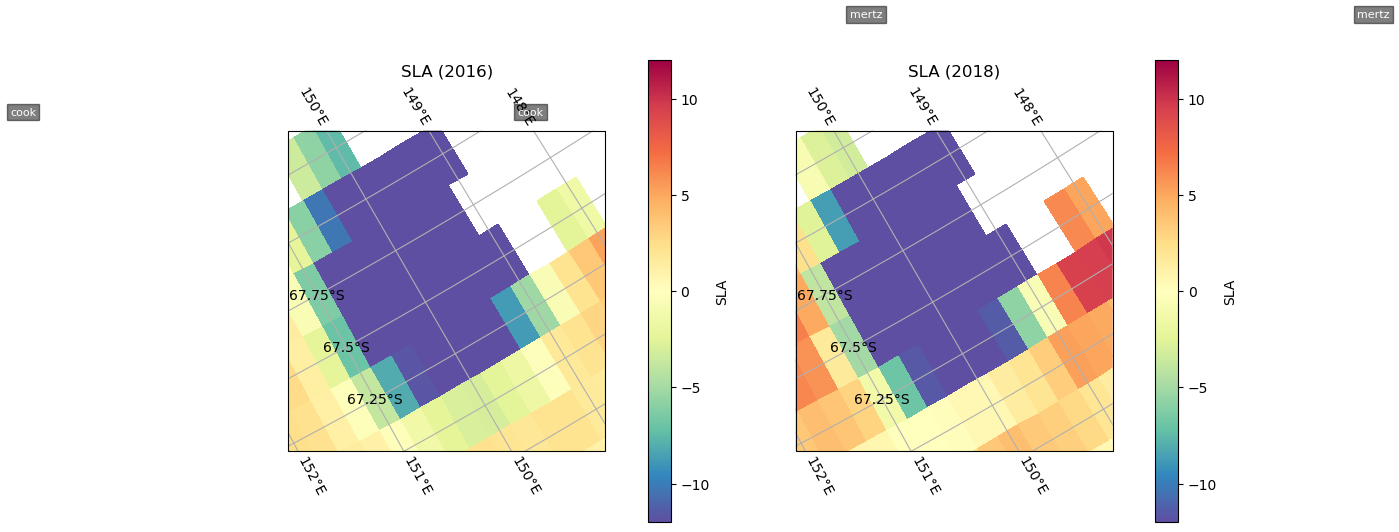

In [19]:
fig, ax = plt.subplots(1,2,figsize=(12,6),subplot_kw={'projection':ccrs.SouthPolarStereo()})
pfns.sp(ax[0],an(sla_anomaly).sel(year=2016),cbar='SLA',vmax=12,title='SLA (2016)',extent=[148.5,151,-68,-67],cbar_orientation='vertical',land_zorder=2)
pfns.sp(ax[1],an(sla_anomaly).sel(year=2018),cbar='SLA',vmax=12,title='SLA (2018)',extent=[148.5,151,-68,-67],cbar_orientation='vertical',land_zorder=2)
plot_glaciers(ax[0])
plot_glaciers(ax[1])

In [ ]:
fig, ax = plt.subplots(1,2,figsize=(12,6),subplot_kw={'projection':ccrs.SouthPolarStereo()})
pfns.sp(ax[0],sla_anomaly.sel(time=pd.Timestamp(2017,12,1),method='nearest'),cbar='SLA',vmax=12,title='SLA (December 2017)',extent=extent,cbar_orientation='vertical',land_zorder=2)
pfns.sp(ax[1],sla_anomaly.sel(time=pd.Timestamp(2019,7,1),method='nearest'),cbar='SLA',vmax=12,title='SLA (July 2019)',extent=extent,cbar_orientation='vertical',land_zorder=2)
plot_glaciers(ax[0])
plot_glaciers(ax[1])

In [11]:
sice = xr.open_dataset('../data/NSIDC/sice_processed.nc')
sice = sice.__xarray_dataarray_variable__
sice = sice.sel(time=slice(sla.time[0],sla.time[-1]))


array([0, 1, 2, 3, 4, 5, 6, 7, 8])

Adding row: Cook
Adding row: Cook
Adding row: Cook Local
Adding row: Hotspot
Rendering..


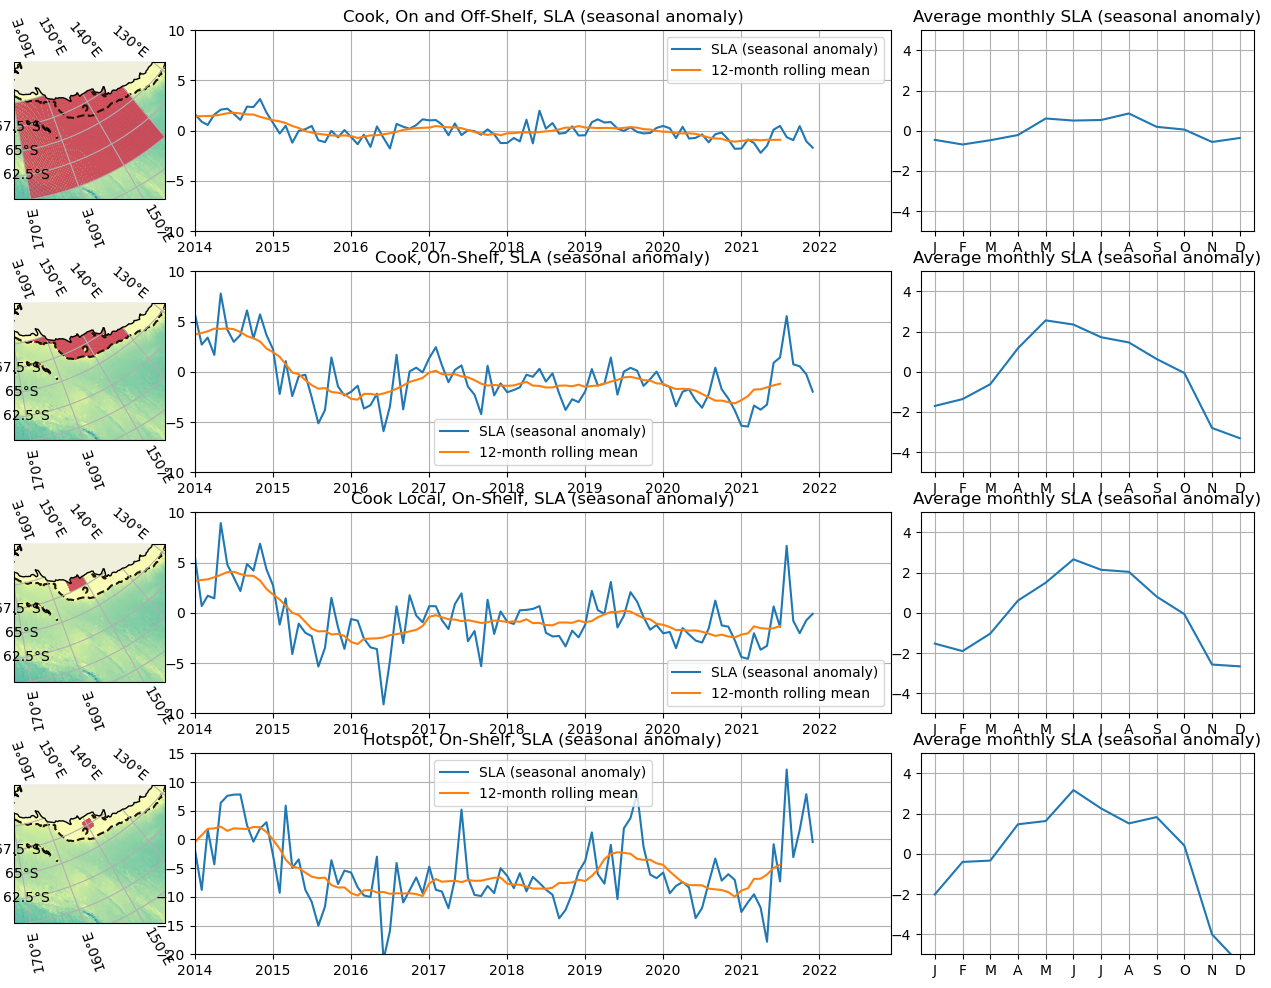

In [28]:
# compare small mertz area to:
# - extended shelf region (135-145)
# - EA south of Amery
# - whole SO (shelf)
fig = plt.figure(figsize=(16,12))
axs=[]

gs = fig.add_gridspec(4,7)

def add_row_anom(n,var,varname,title,extent,map_extent,shelf=False,ylim=[-10,10],ylim_cmt=[-5,5]):

    print('Adding row: ' + title)

    axs.append(fig.add_subplot(gs[n, 0],projection=ccrs.SouthPolarStereo()))
    axs.append(fig.add_subplot(gs[n,1:5]))
    axs.append(fig.add_subplot(gs[n,5:7]))

    if shelf == True:
        region = Region(title, extent, elevation, min_elevation = -1000)
    else:
        region = Region(title, extent, elevation)
    region.plot_region(ax=axs[n*3],da=elevation,extent=map_extent)

    da = region.crop_da(var)

    ax = axs[(n*3)+1]

    cmt = da.groupby('time.month').mean()
    anm = da.groupby('time.month') - cmt
    varname = varname + ' (seasonal anomaly)'

    ax.plot(anm.time,anm.mean(['latitude','longitude']),label=varname)
    #ax.plot(yr(da),an(da).mean(['latitude','longitude']),label=varname + ' ANNUAL')
    ax.plot(anm.time,anm.mean(['latitude','longitude']).rolling(time=12,center=True).mean(),label='12-month rolling mean')

    shelf_str = 'On' if shelf else 'On and Off'
    ax.set_title(title +', '+shelf_str+'-Shelf, ' + varname)
    ax.legend(loc='best')
    ax.set_ylim(ylim)
    ax.set_xlim([pd.Timestamp(2014,1,1),pd.Timestamp(2022,12,1)])
    ax.grid()

    ax = axs[(n*3)+2]

    ax.plot(cmt.month,cmt.mean(['latitude','longitude']))
    ax.set_ylim(ylim_cmt)
    ax.grid()
    ax.set_xticks(np.arange(12)+1)
    ax.set_xticklabels(['J','F','M','A','M','J','J','A','S','O','N','D'])
    ax.set_xlim([0.5,12.5])
    ax.set_title('Average monthly '+varname)

add_row_anom(0,sha_ds_sla.ssha,'SLA','Cook',extent,extent,shelf=False)
add_row_anom(1,sha_ds_sla.ssha,'SLA','Cook',extent,extent,shelf=True)
add_row_anom(2,sha_ds_sla.ssha,'SLA','Cook Local',[150,155,-70,-67.5],extent,shelf=True)
add_row_anom(3,sha_ds_sla.ssha,'SLA','Hotspot',[148.5,151,-68,-67],extent,shelf=True,ylim=[-20,15])


print('Rendering..')
